# Ray API sketch

This notebook is a user-facing sketch of the first-pass ray and imaging API.

The camera and domain-seeding sections below are real code. The later per-cell traversal and rendering sections are still API sketch only.

Design intent:
- exact per-cell `t_enter` and `t_exit` in physical `xyz`
- traversal operates directly on adaptive octree cells
- spherical trees still trace rays in `xyz`
- a small public surface over plain NumPy arrays


## Build the existing octree pieces

The new ray layer sits on top of the current `Octree` and `OctreeInterpolator`.


In [1]:
from batread import Dataset
import numpy as np

from batcamp import Octree
from batcamp import OctreeInterpolator

ds = Dataset.from_file("../sample_data/3d__var_1_n00000000.plt")

tree = Octree(
    points=ds[["X [R]", "Y [R]", "Z [R]"]],
    corners=ds.corners,
)

rho = ds["Rho [g/cm^3]"]
interp = OctreeInterpolator(tree, values=rho)

tree, interp


(<batcamp.octree.Octree at 0x10f3438c0>,
 <batcamp.interpolator.OctreeInterpolator at 0x12e81cd70>)

## Define a camera

For the first pass, the camera surface is just one function returning two arrays:

- `origins`
- `directions`

Both have shape `(ny, nx, 3)`.


In [2]:
from batcamp import camera_rays

camera_origin = np.array([-60.0, 0.0, 0.0])
camera_target = np.array([0.0, 0.0, 0.0])
camera_up = np.array([0.0, 0.0, 1.0])

origins, directions = camera_rays(
    origin=camera_origin,
    target=camera_target,
    up=camera_up,
    nx=11,
    ny=9,
    width=48.0,
    height=36.0,
    projection="parallel",
)

origins.shape, directions.shape


((9, 11, 3), (9, 11, 3))

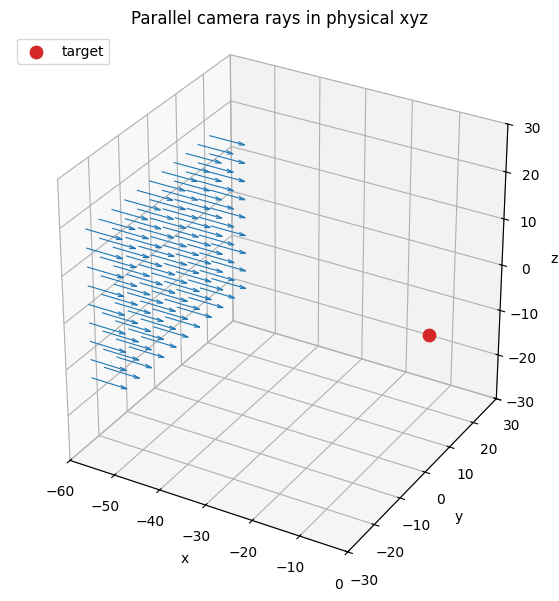

In [3]:
import matplotlib.pyplot as plt

tail = 8.0
origins_flat = origins.reshape(-1, 3)
directions_flat = directions.reshape(-1, 3)
tips_flat = origins_flat + tail * directions_flat

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(
    origins_flat[:, 0],
    origins_flat[:, 1],
    origins_flat[:, 2],
    directions_flat[:, 0],
    directions_flat[:, 1],
    directions_flat[:, 2],
    length=tail,
    normalize=False,
    arrow_length_ratio=0.18,
    linewidth=0.8,
    color="tab:blue",
)
ax.scatter(
    [camera_target[0]],
    [camera_target[1]],
    [camera_target[2]],
    color="tab:red",
    s=80,
    label="target",
)

all_points = np.vstack((origins_flat, tips_flat, camera_target.reshape(1, 3)))
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
span = np.maximum(maxs - mins, 1.0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(span))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Parallel camera rays in physical xyz")
ax.legend(loc="upper left")
plt.show()


## Seed rays inside the octree domain

The first implemented tracer pass only returns one seed point per ray inside the global octree domain.

For the spherical sample tree above, this uses the front visible shell only: once a forward ray hits the opaque inner boundary, the ray is finished.


In [4]:
from batcamp import OctreeRayTracer

tracer = OctreeRayTracer(tree)
seed_xyz = tracer.seed_domain(origins, directions, t_min=0.0, t_max=np.inf)

seed_xyz.shape


(9, 11, 3)

In [5]:
segments = tracer.trace_seed_segments(origins, directions, seed_xyz=seed_xyz)

segments.ray_offsets.shape, segments.cell_ids.shape, segments.t_enter.shape, segments.t_exit.shape


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


((100,), (181,), (181,), (181,))

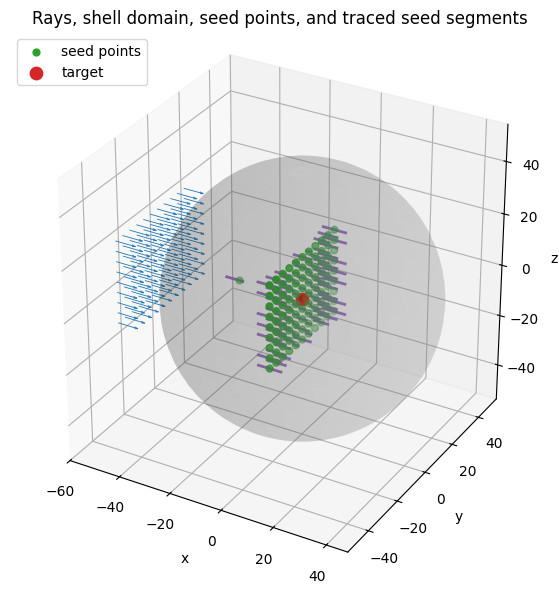

In [6]:
rpa_lo, rpa_hi = tree.domain_bounds(coord="rpa")
r_inner = float(rpa_lo[0])
r_outer = float(rpa_hi[0])

seed_flat = seed_xyz.reshape(-1, 3)
seed_mask = np.isfinite(seed_flat).all(axis=1)
ray_ids = np.repeat(np.arange(origins_flat.shape[0]), np.diff(segments.ray_offsets))
segment_start = origins_flat[ray_ids] + segments.t_enter[:, None] * directions_flat[ray_ids]
segment_end = origins_flat[ray_ids] + segments.t_exit[:, None] * directions_flat[ray_ids]

azimuth = np.linspace(0.0, 2.0 * np.pi, 80)
polar = np.linspace(0.0, np.pi, 40)
azimuth_grid, polar_grid = np.meshgrid(azimuth, polar, indexing="xy")

def sphere_xyz(radius):
    x = radius * np.sin(polar_grid) * np.cos(azimuth_grid)
    y = radius * np.sin(polar_grid) * np.sin(azimuth_grid)
    z = radius * np.cos(polar_grid)
    return x, y, z

outer_x, outer_y, outer_z = sphere_xyz(r_outer)
inner_x, inner_y, inner_z = sphere_xyz(r_inner)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(outer_x, outer_y, outer_z, color="tab:gray", alpha=0.15, linewidth=0.0)
ax.plot_surface(inner_x, inner_y, inner_z, color="tab:orange", alpha=0.45, linewidth=0.0)
ax.quiver(
    origins_flat[:, 0],
    origins_flat[:, 1],
    origins_flat[:, 2],
    directions_flat[:, 0],
    directions_flat[:, 1],
    directions_flat[:, 2],
    length=tail,
    normalize=False,
    arrow_length_ratio=0.18,
    linewidth=0.6,
    color="tab:blue",
)
for p0, p1 in zip(segment_start, segment_end):
    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        [p0[2], p1[2]],
        color="tab:purple",
        linewidth=2.0,
        alpha=0.95,
    )
ax.scatter(
    seed_flat[seed_mask, 0],
    seed_flat[seed_mask, 1],
    seed_flat[seed_mask, 2],
    color="tab:green",
    s=24,
    label="seed points",
)
ax.scatter(
    [camera_target[0]],
    [camera_target[1]],
    [camera_target[2]],
    color="tab:red",
    s=80,
    label="target",
)

sphere_points = np.column_stack((outer_x.reshape(-1), outer_y.reshape(-1), outer_z.reshape(-1)))
all_points = np.vstack((origins_flat, tips_flat, seed_flat[seed_mask], sphere_points, segment_start, segment_end))
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
span = np.maximum(maxs - mins, 1.0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(span))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Rays, shell domain, seed points, and traced seed segments")
ax.legend(loc="upper left")
plt.show()


## Trace adaptive octree segments

The first real traced seed neighborhood is now `trace_seed_segments(...)`, which returns up to two packed segments per ray around the domain seed.

```python
segments = tracer.trace_seed_segments(origins, directions, seed_xyz=seed_xyz)

segments.ray_offsets.shape
segments.cell_ids.shape
segments.t_enter.shape
segments.t_exit.shape
```

The later full `trace(...)` method should generalize that seed-neighborhood result into the whole two-way walk through the adaptive octree.


## Render a first image

A single opinionated helper is enough for the first pass:

```python
from batcamp import render_midpoint_image

image = render_midpoint_image(
    interpolator=interp,
    segments=segments,
)

image.shape
```


## Low-level contract

The minimal public surface this sketch assumes is:

- `camera_rays(...)`
- `OctreeRayTracer.seed_domain(...)` returning `seed_xyz`
- later: `OctreeRayTracer.trace(...)`
- later: `RaySegments` with `ray_offsets`, `cell_ids`, `t_enter`, `t_exit`
- later: `render_midpoint_image(...)`

Everything beyond domain clipping can stay private until the first traversal implementation is working.
